In [ ]:
import pandas as pd 

df_label = pd.read_csv("data\Descriptif_patients(Sheet1).csv", sep = ";")

df_label['id'] = range(1, len(df_label) + 1)

df_label.to_csv("data\Descriptif_patients(Sheet1).csv", index = False, sep = ";")


<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
C:\Users\mathe\AppData\Local\Temp\ipykernel_19552\789226142.py:3: SyntaxWarning: invalid escape sequence '\D'
  df_label = pd.read_csv("data\Descriptif_patients(Sheet1).csv", sep = ";")
C:\Users\mathe\AppData\Local\Temp\ipykernel_19552\789226142.py:7: SyntaxWarning: invalid escape sequence '\D'
  df_label.to_csv("data\Descriptif_patients(Sheet1).csv", index = False, sep = ";")


In [18]:
df_res = pd.read_csv("data/Relectures_imageries(Feuil1).csv", sep = ";")
df_label = pd.read_csv("data/Descriptif_patients(Sheet1).csv", sep = ";")

df_res["patient_num"] = df_res["Patient_number"]



dictionnaire_tumeurs = {
    1: 'CCK',
    2: 'CHC',
    3: 'Mixtes'
}

df_res['Type_tumeur'] = df_res['Type_tumeur'].replace(dictionnaire_tumeurs)

df_res["classe_name"] = df_res["Type_tumeur"]

df_res = df_res.drop(columns = ["Patient_number", "Type_tumeur"])

df_res = pd.merge(
    df_res, 
    df_label[['patient_num', 'classe_name', 'id']], 
    on=['patient_num', 'classe_name'], 
    how='left'
)

df_res.to_csv("data/Relectures_imageries.csv", sep = ";", index = False)



In [20]:
df_res['id'] = df_res['id'].astype('Int64')
df_res.to_csv("data\Relectures_imageries.csv", sep = ";", index = False)


<>:2: SyntaxWarning: invalid escape sequence '\R'
<>:2: SyntaxWarning: invalid escape sequence '\R'
C:\Users\mathe\AppData\Local\Temp\ipykernel_20664\3257519629.py:2: SyntaxWarning: invalid escape sequence '\R'
  df_res.to_csv("data\Relectures_imageries.csv", sep = ";", index = False)


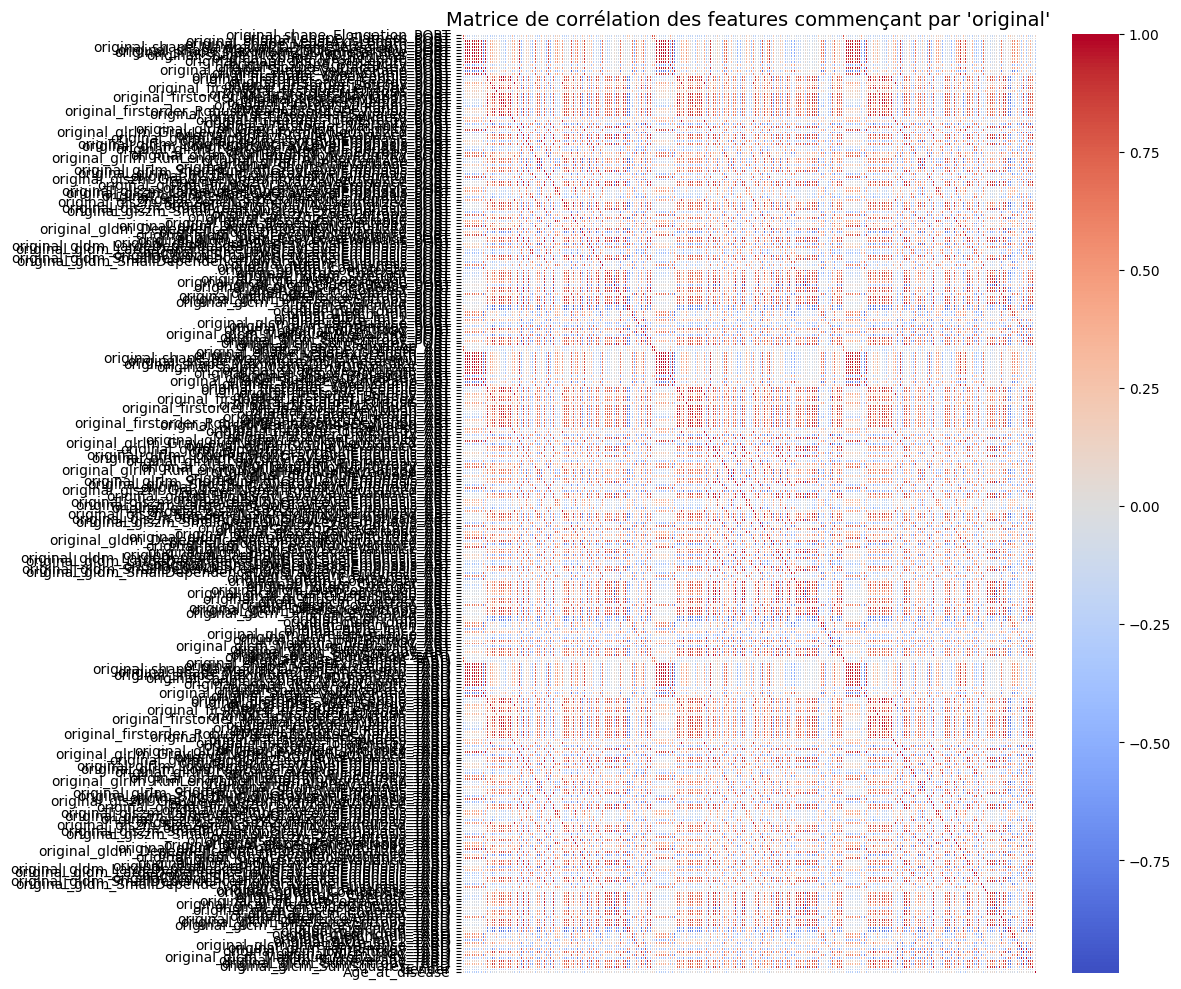

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Si ton dataframe n'est pas déjà chargé
# df_res = pd.read_csv("data/global_excel_resampled_scaled.csv")

df_res = pd.read_csv("data/flattened_global_scaled.csv", sep = ";")

# 2. Filtrer les colonnes qui commencent exactement par 'original'
# On peut utiliser une compréhension de liste :
cols_original = [col for col in df_res.columns if col.startswith('original')]

# (Alternative plus rapide avec Pandas directement)
# df_original = df_res.filter(regex='^original') 
df_original = df_res[cols_original + ["Gender", "Age_at_disease"]]

# 3. Calculer la matrice de corrélation (Pearson par défaut)
corr_matrix = df_original.corr()

# 4. Tracer la matrice de corrélation
plt.figure(figsize=(12, 10)) # Tu peux ajuster la taille si tu as beaucoup de features

# Création de la heatmap
sns.heatmap(
    corr_matrix, 
    annot=False,       # Passe à True si tu veux afficher les valeurs exactes des corrélations
    cmap='coolwarm',   # Code couleur : Rouge = corrélation positive (+1), Bleu = négative (-1)
    center=0,          # Centre les couleurs sur 0
    linewidths=0.5,    # Ajoute de légères lignes entre les cases pour la lisibilité
    xticklabels=False, # Cacher les labels X s'il y en a trop (mets True pour les voir)
    yticklabels=True   # Afficher les labels sur l'axe Y
)

plt.title("Matrice de corrélation des features commençant par 'original'", fontsize=14)
plt.tight_layout()

# Afficher le graphique
plt.show()

c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


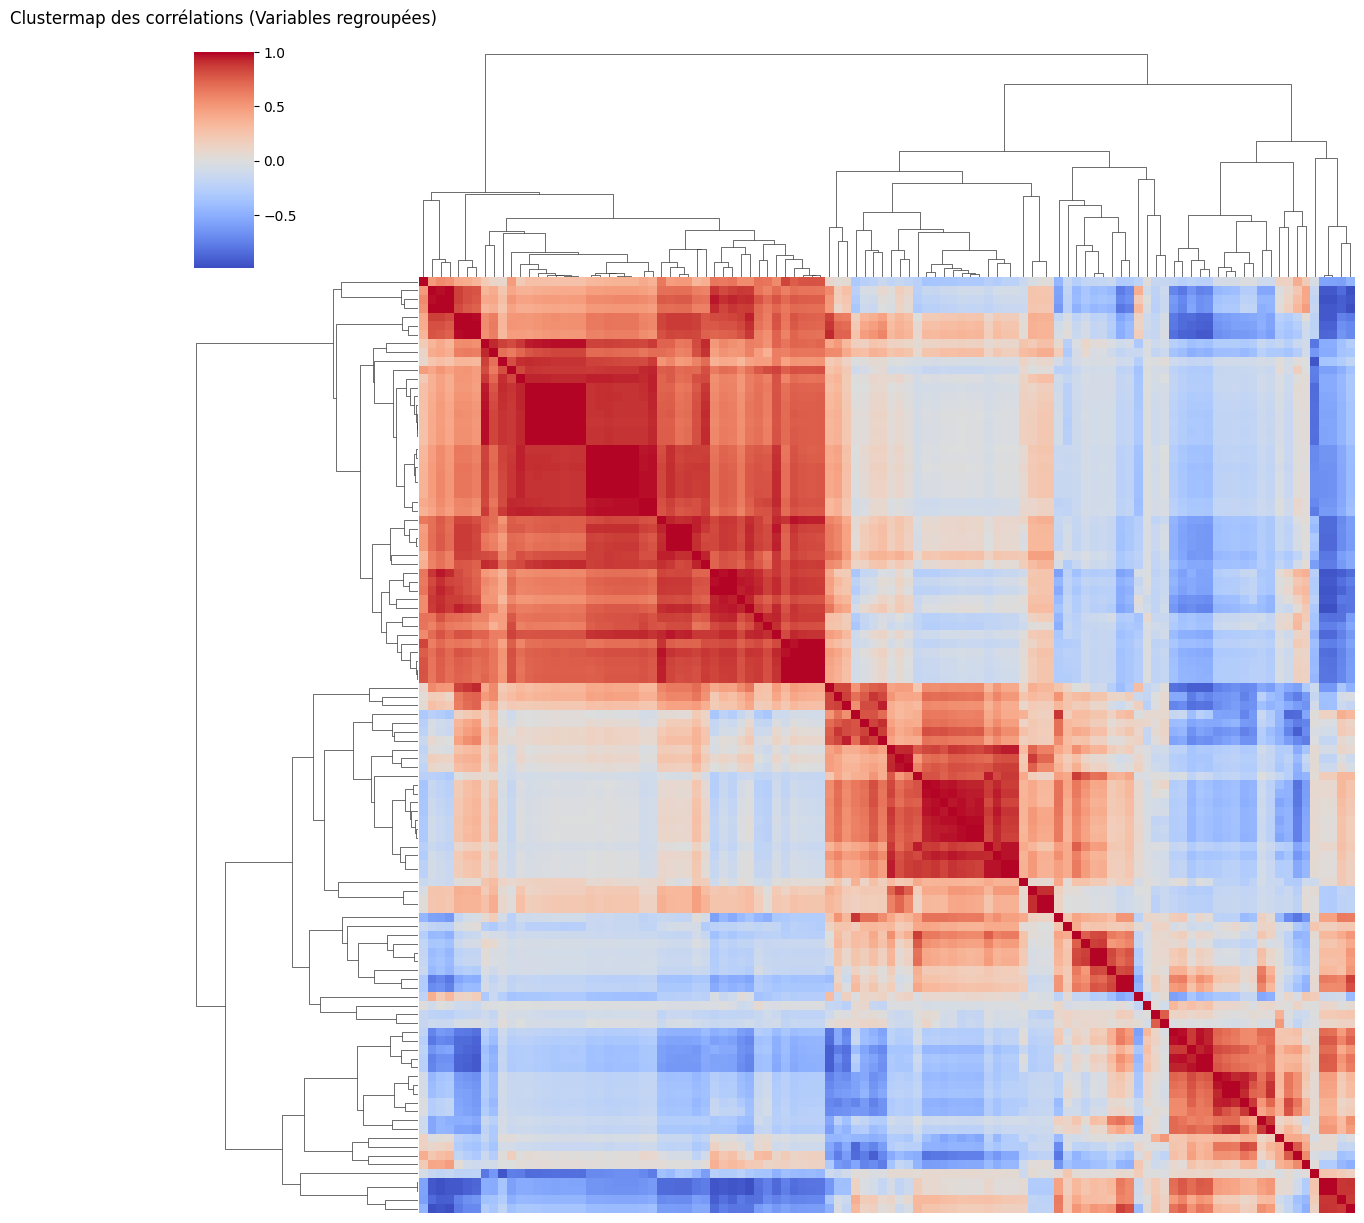

In [28]:
# Remplacer sns.heatmap par sns.clustermap
g = sns.clustermap(
    corr_matrix, 
    cmap='coolwarm', 
    center=0, 
    figsize=(12, 12),
    xticklabels=False, # On cache le texte en X
    yticklabels=False, # On cache le texte en Y (trop nombreux)
    linewidths=0       # Enlever les bordures aide la lisibilité sur les grosses matrices
)

plt.title("Clustermap des corrélations (Variables regroupées)", pad=20)
plt.show()

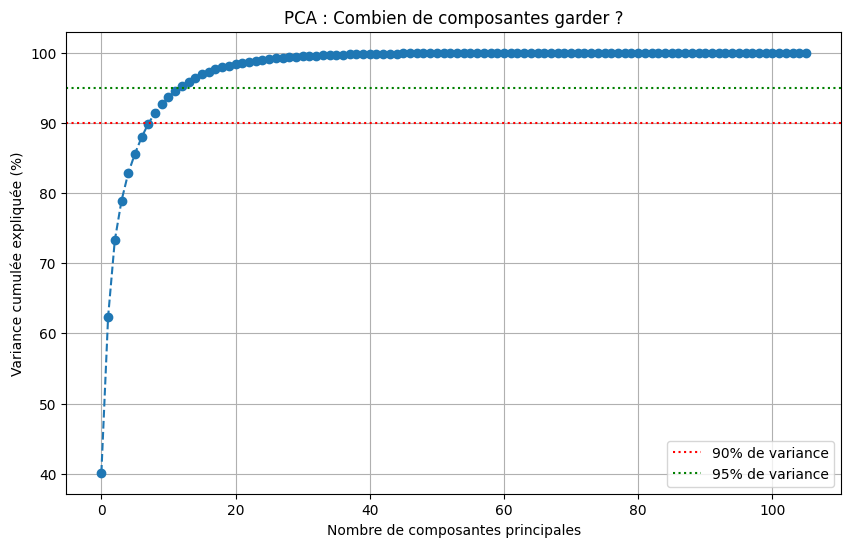

In [29]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Préparation des données (on reprend df_original)
# On s'assure qu'il n'y a pas de valeurs manquantes
X = df_original.dropna() 

# 2. Standardisation (Étape OBLIGATOIRE avant une PCA)
# Même si ton fichier s'appelle "scaled", c'est toujours bien de s'en assurer
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Calcul de la PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 4. Visualisation de la variance expliquée
plt.figure(figsize=(10, 6))
# On trace la somme cumulée du pourcentage de variance expliquée
plt.plot(np.cumsum(pca.explained_variance_ratio_) * 100, marker='o', linestyle='--')

# Ligne de repère visuel à 90% et 95% d'information conservée
plt.axhline(y=90, color='r', linestyle=':', label='90% de variance')
plt.axhline(y=95, color='g', linestyle=':', label='95% de variance')

plt.xlabel('Nombre de composantes principales')
plt.ylabel('Variance cumulée expliquée (%)')
plt.title('PCA : Combien de composantes garder ?')
plt.legend()
plt.grid(True)
plt.show()

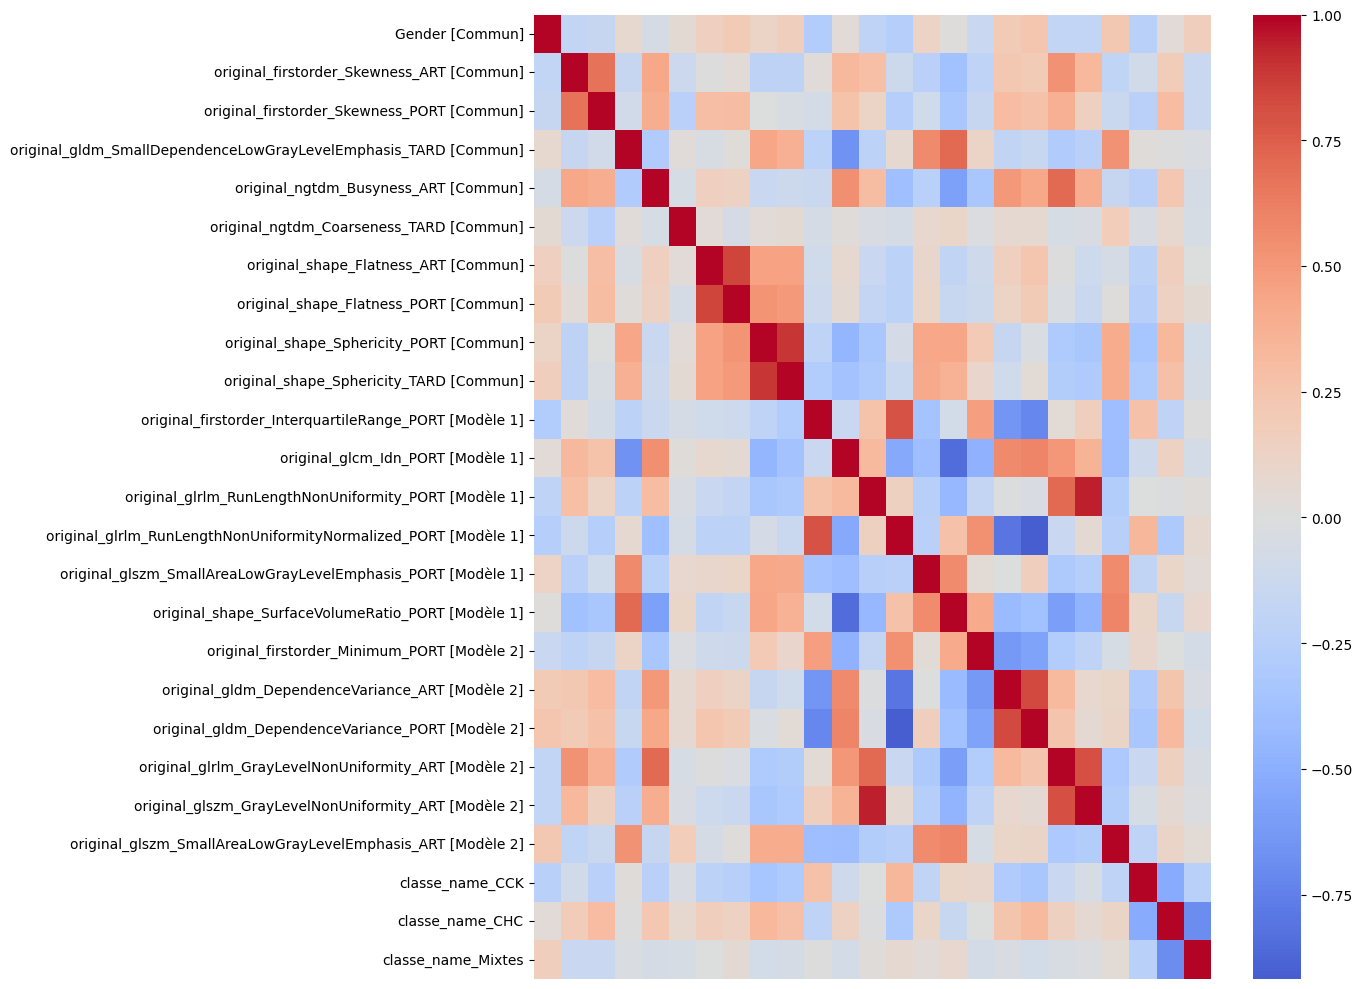

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Listes de répartition des variables
features_commun = [
    "Gender", "original_firstorder_Skewness_ART", "original_firstorder_Skewness_PORT",
    "original_gldm_SmallDependenceLowGrayLevelEmphasis_TARD", "original_ngtdm_Busyness_ART",
    "original_ngtdm_Coarseness_TARD", "original_shape_Flatness_ART", "original_shape_Flatness_PORT",
    "original_shape_Sphericity_PORT", "original_shape_Sphericity_TARD"
]

features_modele_1 = [
    "original_firstorder_InterquartileRange_PORT", "original_glcm_Idn_PORT",
    "original_glrlm_RunLengthNonUniformity_PORT", "original_glrlm_RunLengthNonUniformityNormalized_PORT",
    "original_glszm_SmallAreaLowGrayLevelEmphasis_PORT", "original_shape_SurfaceVolumeRatio_PORT"
]

features_modele_2 = [
    "original_firstorder_Minimum_PORT", "original_gldm_DependenceVariance_ART",
    "original_gldm_DependenceVariance_PORT", "original_glrlm_GrayLevelNonUniformity_ART",
    "original_glszm_GrayLevelNonUniformity_ART", "original_glszm_SmallAreaLowGrayLevelEmphasis_ART"
]

# Chargement des données
df_res = pd.read_csv("data/flattened_global_scaled.csv", sep=";")

# On utilise directement nos 3 listes pour définir les colonnes à garder
cols_original = features_commun + features_modele_1 + features_modele_2 + ["classe_name"]
df_corr = df_res[cols_original]

# One-hot encoding
df_encoded = pd.get_dummies(df_corr, columns=['classe_name'], dtype=int)

# 2. Calcul de la matrice de corrélation
corr_matrix_with_target = df_encoded.corr()

# 3. Création du dictionnaire de renommage et de la liste du NOUVEL ORDRE
label_mapping = {}
ordered_labels = []

# -- Ajout des Communs --
for col in features_commun:
    new_name = f"{col} [Commun]"
    label_mapping[col] = new_name
    ordered_labels.append(new_name)

# -- Ajout du Modèle 1 --
for col in features_modele_1:
    new_name = f"{col} [Modèle 1]"
    label_mapping[col] = new_name
    ordered_labels.append(new_name)

# -- Ajout du Modèle 2 --
for col in features_modele_2:
    new_name = f"{col} [Modèle 2]"
    label_mapping[col] = new_name
    ordered_labels.append(new_name)

# -- Ajout des variables de classe (Target) à la toute fin --
target_cols = [col for col in corr_matrix_with_target.columns if col.startswith('classe_name')]
for col in target_cols:
    label_mapping[col] = col
    ordered_labels.append(col)

# 4. Application du renommage sur la matrice
corr_matrix_with_target = corr_matrix_with_target.rename(index=label_mapping, columns=label_mapping)

# 5. REORGANISATION de la matrice selon l'ordre défini
corr_matrix_ordered = corr_matrix_with_target.loc[ordered_labels, ordered_labels]

# 6. Affichage avec Heatmap
plt.figure(figsize=(14, 10)) # Taille ajustée pour bien voir les groupes
sns.heatmap(
    corr_matrix_ordered, 
    cmap='coolwarm', 
    center=0, 
    xticklabels=False, 
    yticklabels=True,
    linewidths=0
)

plt.tight_layout() 
plt.show()

c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


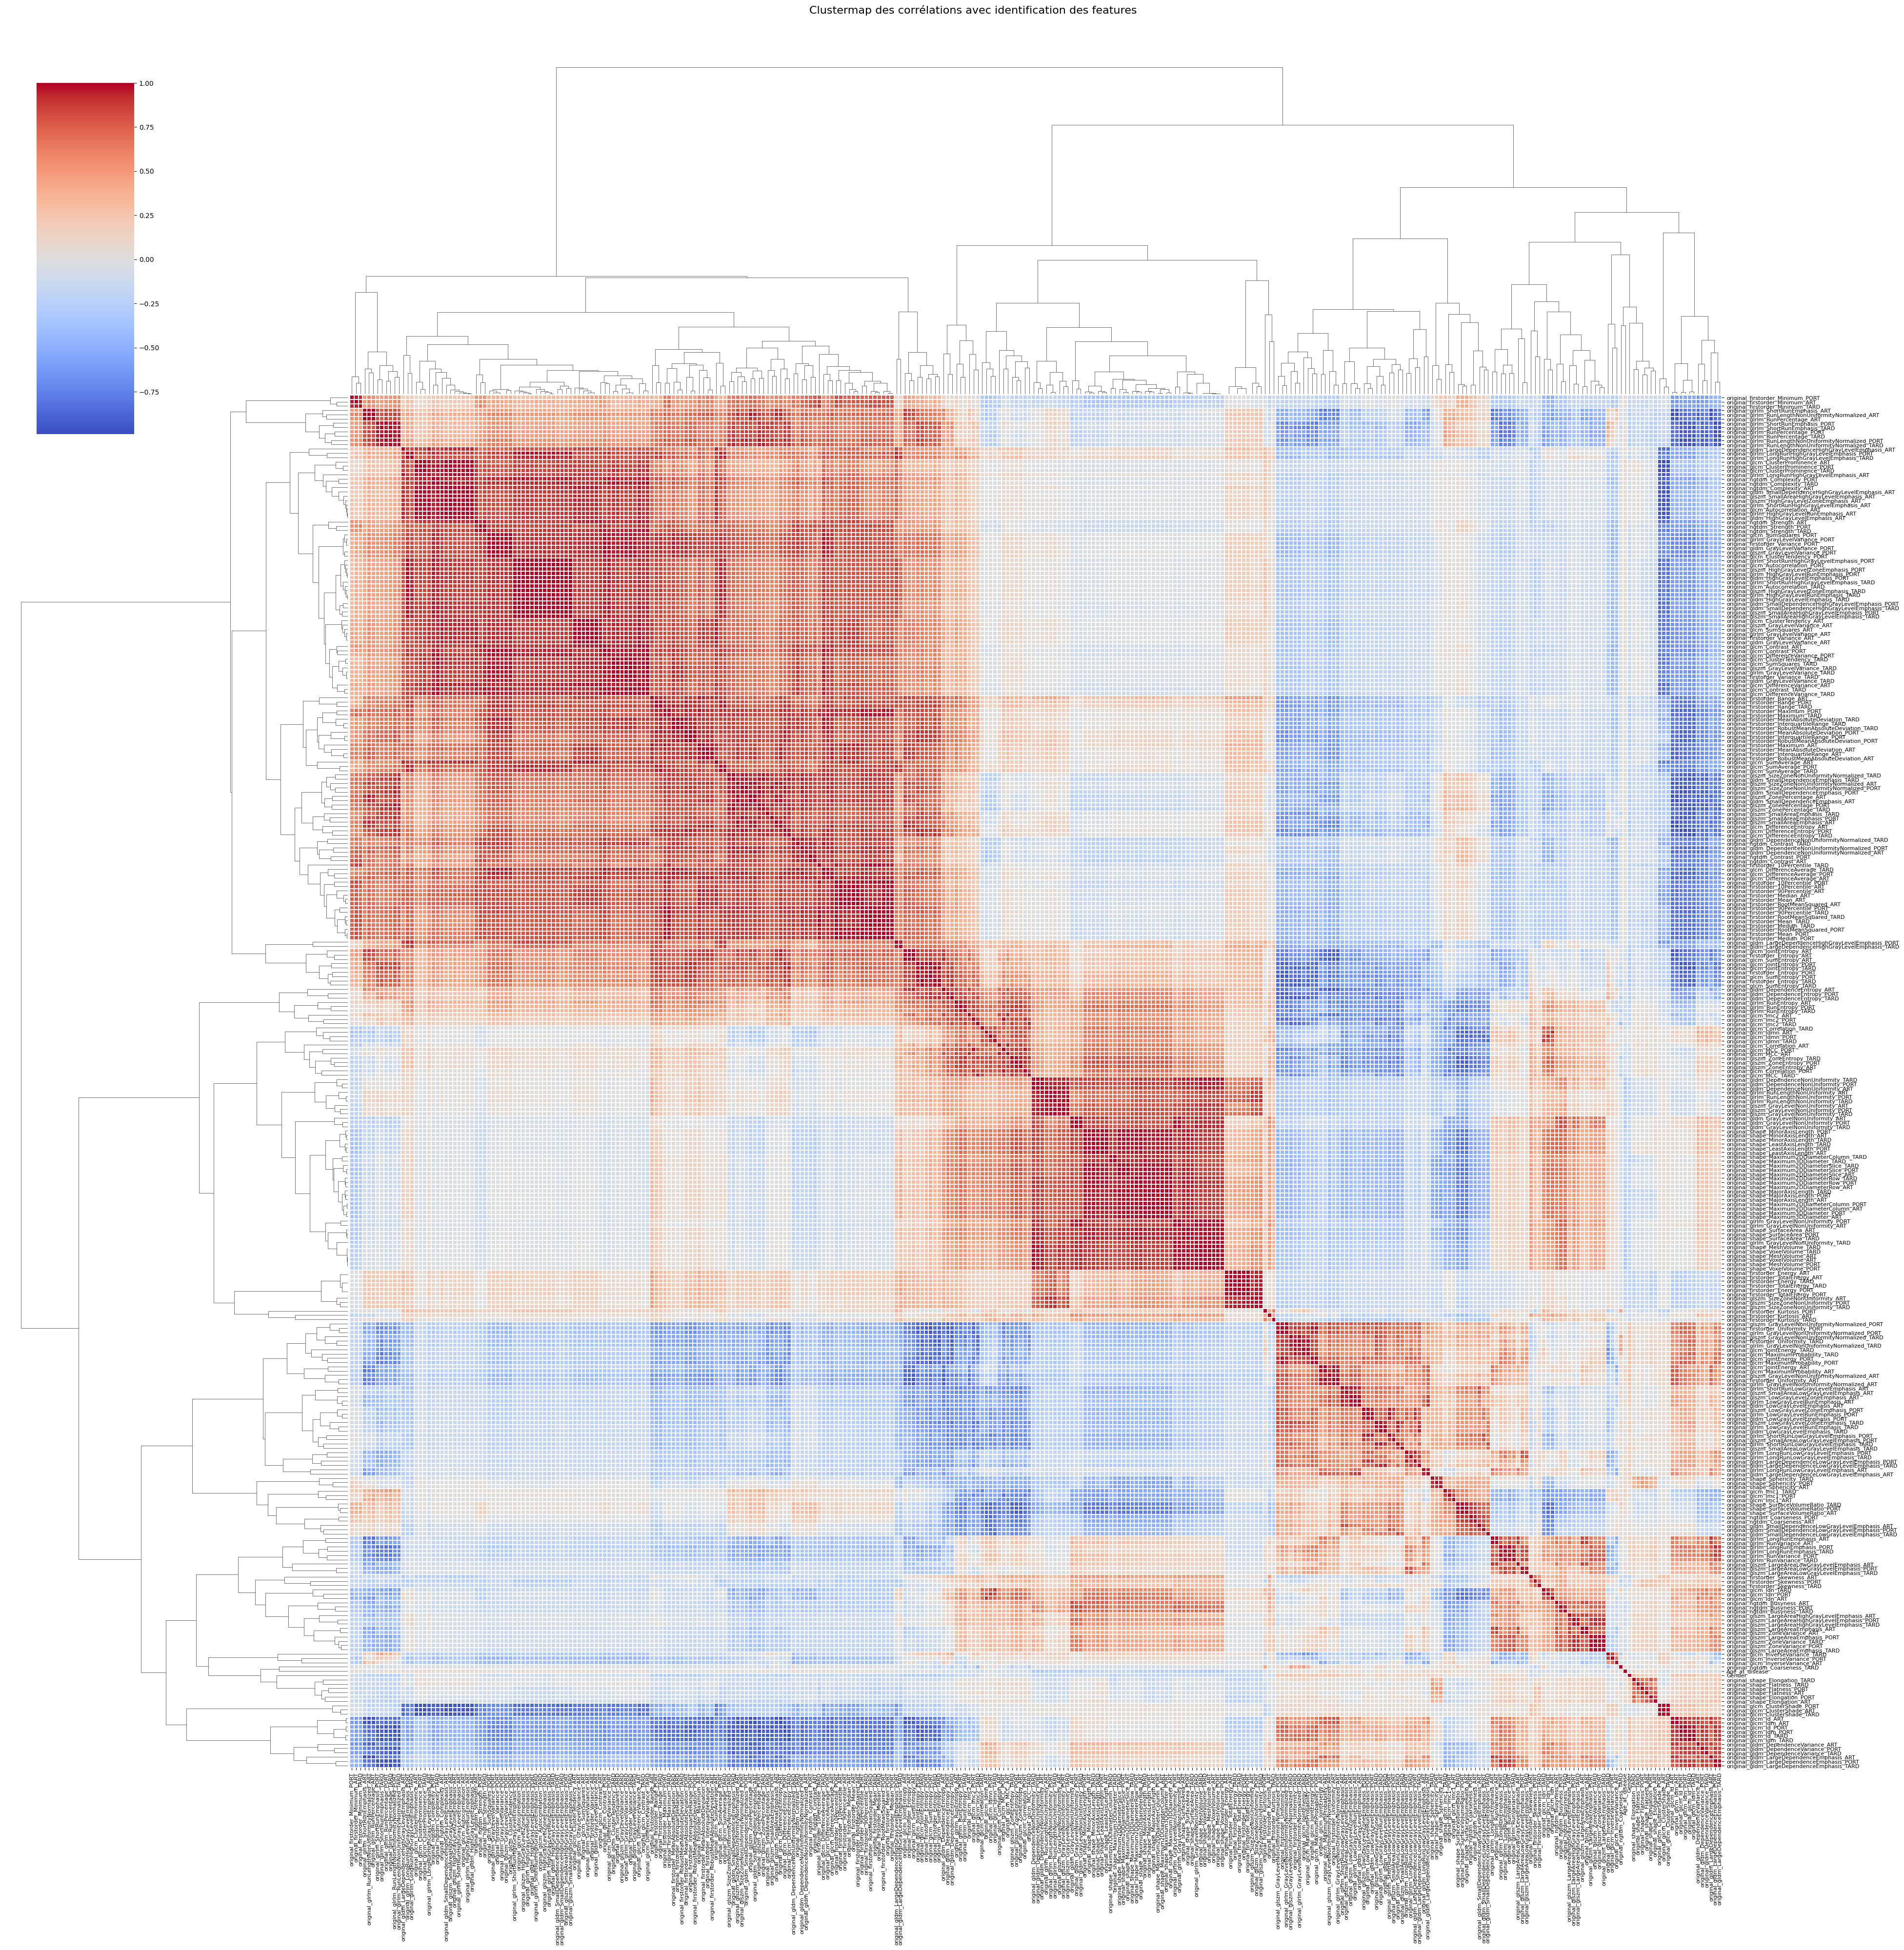

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Création du Clustermap (en activant les labels)
g = sns.clustermap(
    corr_matrix,          # Ta matrice de corrélation calculée précédemment
    cmap='coolwarm', 
    center=0, 
    figsize=(40, 40),     # On augmente drastiquement la taille (20x20)
    xticklabels=True,     # ON AFFICHE les colonnes
    yticklabels=True,     # ON AFFICHE les lignes
    linewidths=0.1
)

# 2. Ajustement de la taille et de la rotation du texte pour la lisibilité
# On force une petite police (fontsize=8 ou 6 selon le nombre de features)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=8) 
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)

plt.suptitle("Clustermap des corrélations avec identification des features", y=1.02, fontsize=16)

# Affichage
plt.show()

In [13]:
df = pd.read_csv("data/parametres_correlation.csv", sep = ";")

col_a_garder = ["Variable_Clinique", "Feature_1", "Feature_2", "Feature_3"]

df_vf = df[col_a_garder]

df_vf.to_csv("data/param_correlation.csv", sep = ";", index = False)


c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


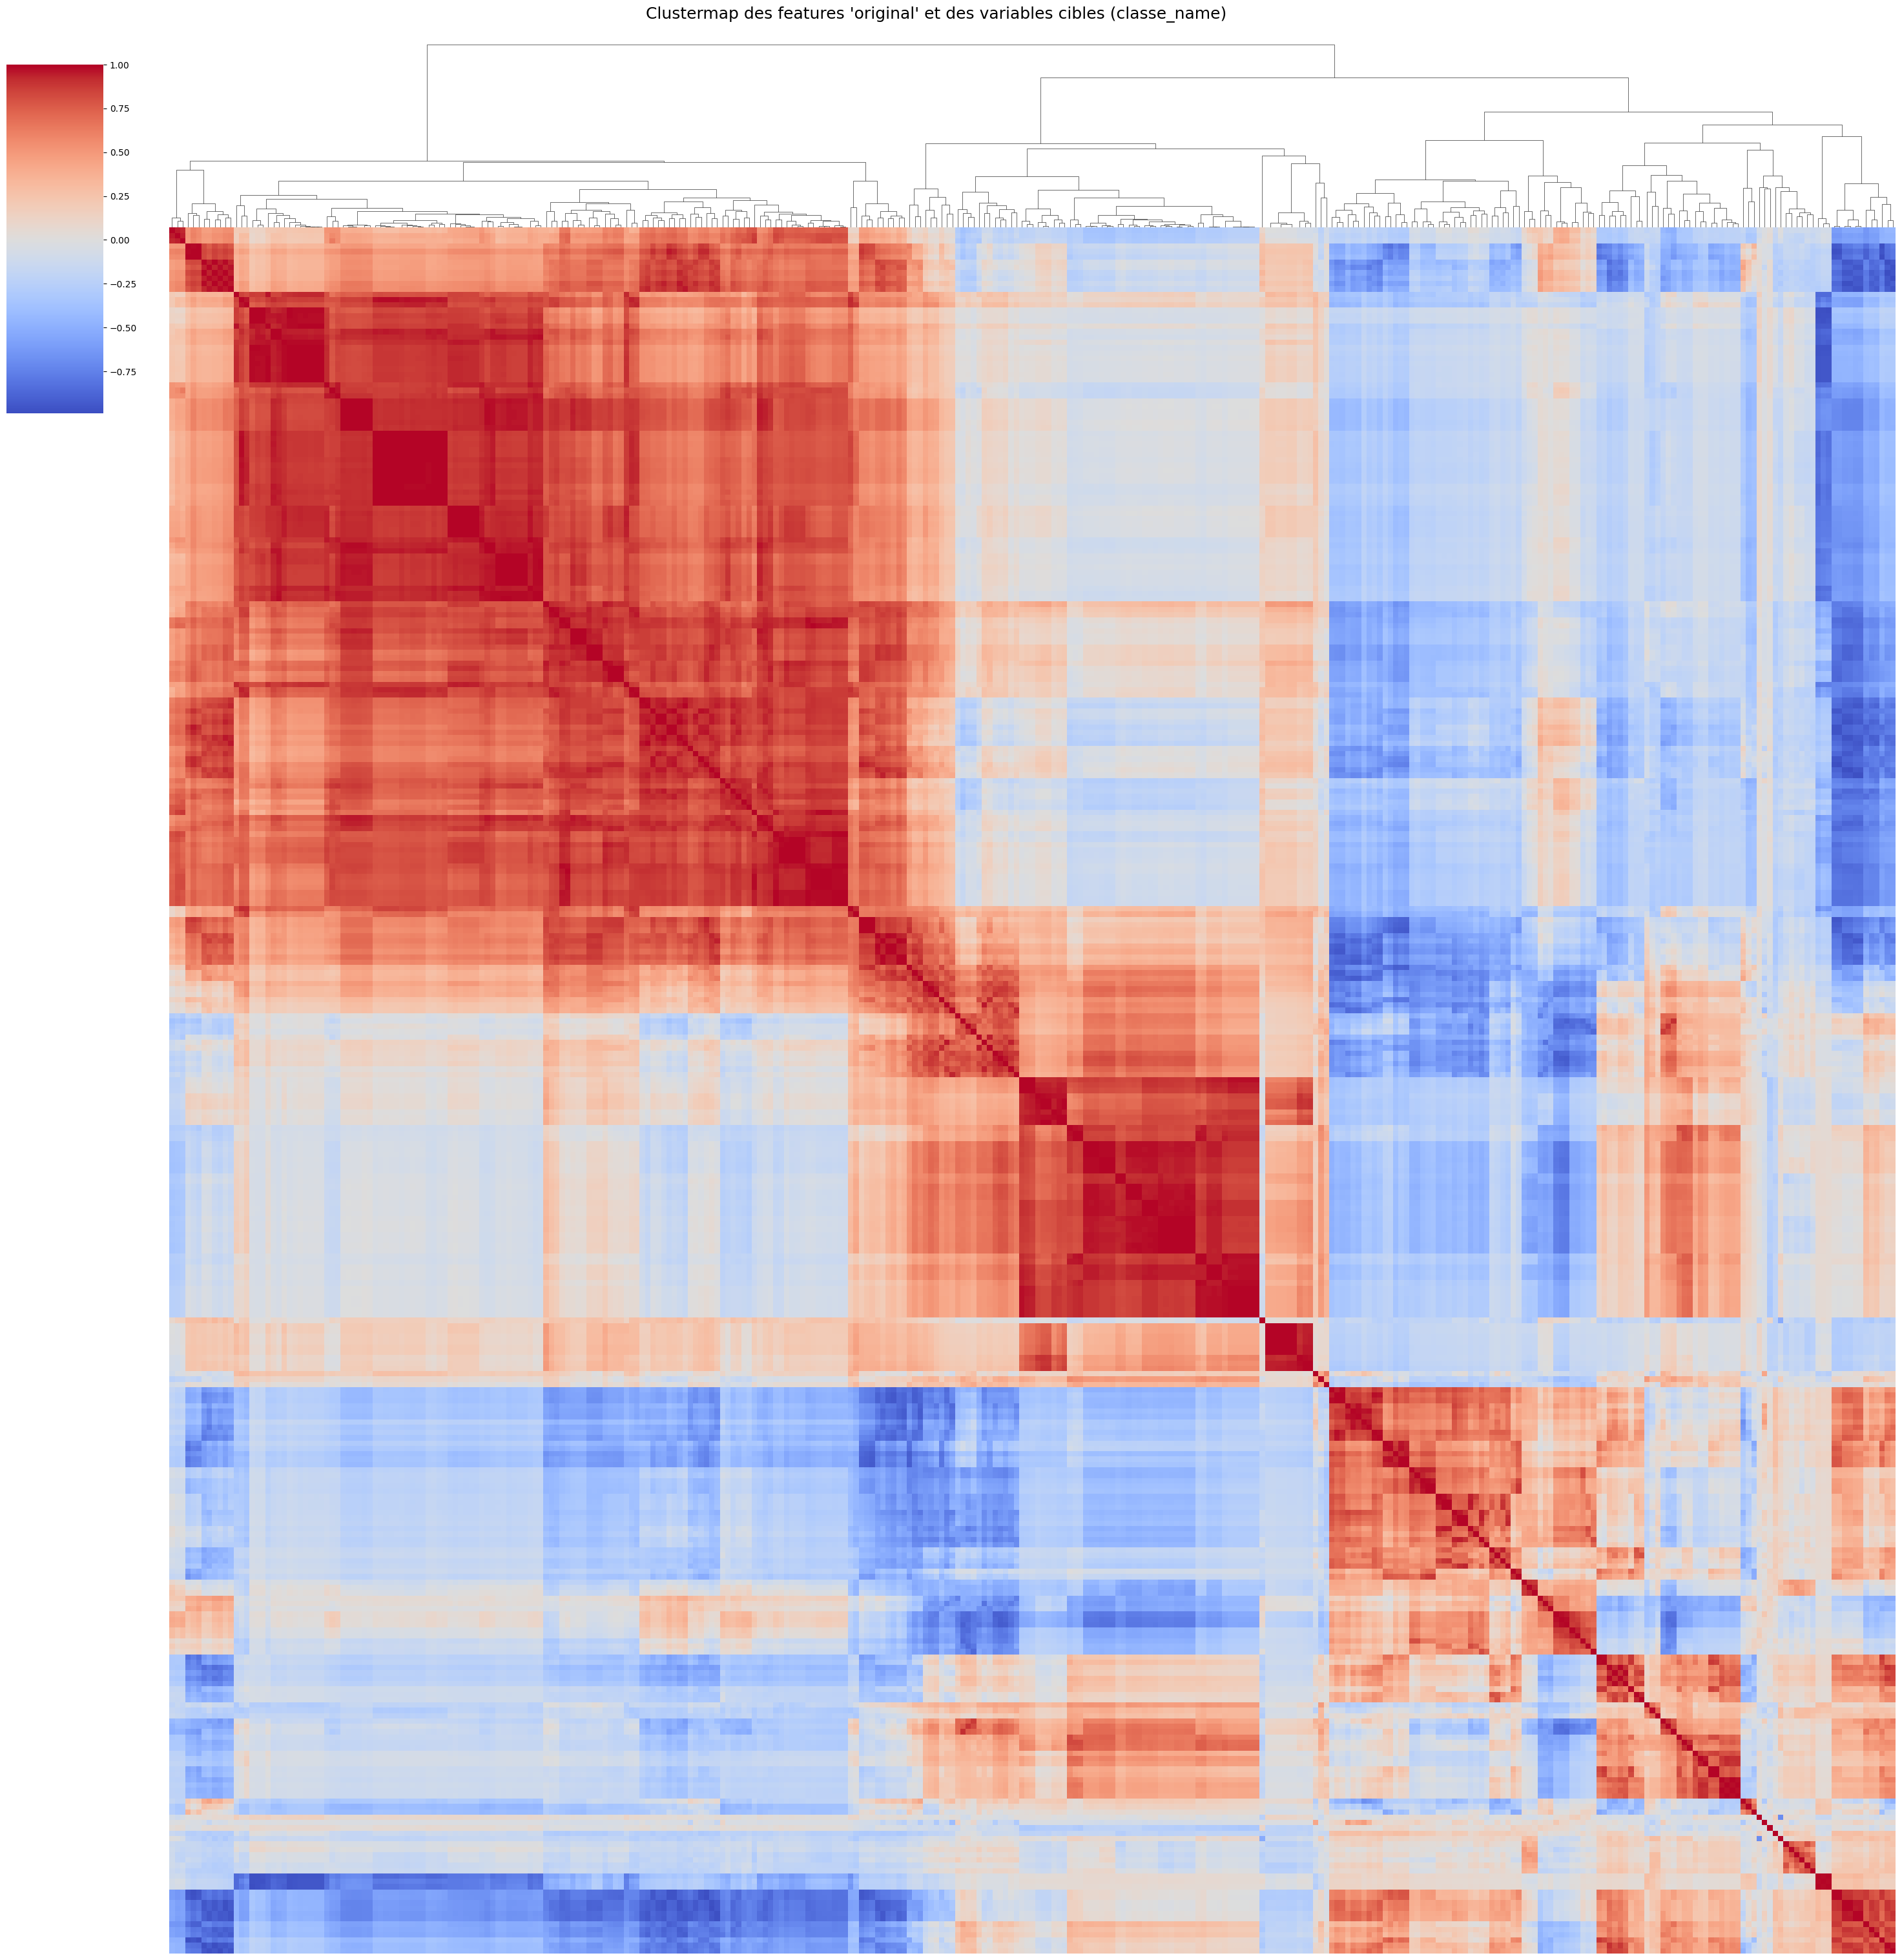

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_res = pd.read_csv("data/flattened_global_scaled.csv", sep = ";")

# 1. Sélection des features 'original' et de la cible 'classe_name'
cols_original = [col for col in df_res.columns if col.startswith('original')]
df_corr = df_res[cols_original + ['classe_name', 'Gender', 'Age_at_disease']].dropna()

# 2. Encodage de la cible en 3 colonnes distinctes (0 ou 1)
# Cela va créer : classe_name_CHC, classe_name_CCK, classe_name_Mixtes
df_encoded = pd.get_dummies(df_corr, columns=['classe_name'], dtype=int)

# 3. Calcul de la matrice de corrélation globale
corr_matrix_with_target = df_encoded.corr()

# 4. Création du Clustermap géant pour afficher TOUS les noms
g = sns.clustermap(
    corr_matrix_with_target, 
    cmap='coolwarm', 
    center=0, 
    figsize=(30, 30),       # Taille XXL (30x30) pour donner de l'espace au texte
    xticklabels=False,       # Affiche les noms en bas
    yticklabels=False,       # Affiche les noms sur le côté
    linewidths=0.001,        # Lignes très fines entre les cellules
    dendrogram_ratio=0.1  # Réduit la taille de l'arbre pour laisser plus de place à la carte
)

g.ax_row_dendrogram.set_visible(False)

# 5. Ajustement précis de la police et de la rotation des étiquettes
# On utilise une taille de police de 6 pour éviter que les noms se marchent dessus
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=6, ha='right') 
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=6)

# Titre du graphique
plt.suptitle("Clustermap des features 'original' et des variables cibles (classe_name)", y=1.01, fontsize=18)

# Affichage
plt.show()

In [42]:
import pandas as pd
import numpy as np

df_res = pd.read_csv("data/global_excel_resampled_normalized_flattened.csv", sep = ";")

# 1. On recrée le sous-dataframe avec uniquement les features 'original'
cols_original = [col for col in df_res.columns if col.startswith('original')]
df_original = df_res[cols_original + ['Gender', 'Age_at_disease',]]

# 2. Calcul de la matrice de corrélation en valeurs absolues 
# (car une corrélation de -0.95 est tout aussi redondante que +0.95)
corr_matrix_abs = df_original.corr().abs()

# 3. Sélection du triangle supérieur de la matrice
# Cela permet de ne pas comparer la feature avec elle-même, et d'éviter de supprimer les DEUX features d'un couple
upper_triangle = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

# 4. Identification des colonnes à supprimer (celles avec une corrélation > 0.90)
features_a_supprimer = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.8)]

# 5. Déduction des features à CONSERVER
features_a_conserver = [col for col in df_original.columns if col not in features_a_supprimer]

# 6. Création du tableau final
df_features_conservees = pd.DataFrame({
    "Features à conserver": features_a_conserver
})

# On commence l'index à 1 pour que ce soit plus joli à lire
df_features_conservees.index = range(1, len(df_features_conservees) + 1)

# --- AFFICHAGE ---
print(f"Résumé du nettoyage :")
print(f"- Features initiales : {len(df_original.columns)}")
print(f"- Features supprimées : {len(features_a_supprimer)}")
print(f"- Features conservées : {len(features_a_conserver)}")
print("\nTableau des features à conserver :")

# Si tu es sur Jupyter Notebook, utilise display() qui fera un beau tableau HTML :
print(df_features_conservees) 
print(features_a_conserver)
# Si tu utilises un autre éditeur (Spyder, VSCode...), utilise plutôt :
# print(df_features_conservees)

Résumé du nettoyage :
- Features initiales : 320
- Features supprimées : 293
- Features conservées : 27

Tableau des features à conserver :
                               Features à conserver
1                    original_shape_Elongation_PORT
2                      original_shape_Flatness_PORT
3               original_shape_LeastAxisLength_PORT
4                    original_shape_Sphericity_PORT
5             original_firstorder_10Percentile_PORT
6                   original_firstorder_Energy_PORT
7                  original_firstorder_Entropy_PORT
8                 original_firstorder_Kurtosis_PORT
9                 original_firstorder_Skewness_PORT
10              original_glrlm_LongRunEmphasis_PORT
11  original_glrlm_LongRunLowGrayLevelEmphasis_PORT
12      original_glrlm_LowGrayLevelRunEmphasis_PORT
13                   original_glrlm_RunEntropy_PORT
14                          original_glcm_Imc1_PORT
15               original_glcm_InverseVariance_PORT
16                 original_

In [43]:
colonnes_finales = features_a_conserver + ['classe_name', 'id', 'patient_num']
print(colonnes_finales)
df_clean = df_res[colonnes_finales]
df_clean.head()

['original_shape_Elongation_PORT', 'original_shape_Flatness_PORT', 'original_shape_LeastAxisLength_PORT', 'original_shape_Sphericity_PORT', 'original_firstorder_10Percentile_PORT', 'original_firstorder_Energy_PORT', 'original_firstorder_Entropy_PORT', 'original_firstorder_Kurtosis_PORT', 'original_firstorder_Skewness_PORT', 'original_glrlm_LongRunEmphasis_PORT', 'original_glrlm_LongRunLowGrayLevelEmphasis_PORT', 'original_glrlm_LowGrayLevelRunEmphasis_PORT', 'original_glrlm_RunEntropy_PORT', 'original_glcm_Imc1_PORT', 'original_glcm_InverseVariance_PORT', 'original_firstorder_Kurtosis_ART', 'original_firstorder_Skewness_ART', 'original_glrlm_LongRunLowGrayLevelEmphasis_ART', 'original_glrlm_LowGrayLevelRunEmphasis_ART', 'original_glcm_InverseVariance_ART', 'original_shape_Elongation_TARD', 'original_firstorder_Kurtosis_TARD', 'original_firstorder_Skewness_TARD', 'original_glrlm_LowGrayLevelRunEmphasis_TARD', 'original_ngtdm_Coarseness_TARD', 'Gender', 'Age_at_disease', 'classe_name', '

,original_shape_Elongation_PORT,original_shape_Flatness_PORT,original_shape_LeastAxisLength_PORT,original_shape_Sphericity_PORT,original_firstorder_10Percentile_PORT,original_firstorder_Energy_PORT,original_firstorder_Entropy_PORT,original_firstorder_Kurtosis_PORT,original_firstorder_Skewness_PORT,original_glrlm_LongRunEmphasis_PORT,...,original_shape_Elongation_TARD,original_firstorder_Kurtosis_TARD,original_firstorder_Skewness_TARD,original_glrlm_LowGrayLevelRunEmphasis_TARD,original_ngtdm_Coarseness_TARD,Gender,Age_at_disease,classe_name,id,patient_num
0,0.038251,-1.176011,-0.411871,-1.892263,-0.058631,-0.039535,0.321836,-0.058631,-0.058631,-0.461657,...,0.230961,-0.058631,-0.058631,-0.698913,-0.048970,0.581140,-0.068423,CCK,1,10
1,0.476990,0.723917,-0.411839,-0.053657,-0.058631,-0.011057,2.760722,-0.058631,-0.058631,-0.937262,...,0.476990,-0.058631,-0.058631,-0.739025,-0.048970,-1.707099,-0.498051,CCK,2,11
2,-0.051245,0.263537,0.136130,-1.063784,-0.058631,-0.031062,-0.184591,-0.058631,-0.058631,0.134166,...,-0.095452,-0.058631,-0.058631,-0.589264,-0.048970,0.581140,-0.412126,CCK,3,12
3,1.350355,0.609722,-0.699797,1.129433,-0.058631,-0.057466,-0.928835,-0.058631,-0.058631,0.163076,...,1.196603,-0.058631,-0.058631,0.815930,-0.048970,0.581140,0.103428,CCK,5,14
4,0.400567,0.458591,-1.040265,1.219839,-0.058631,-0.057644,0.173673,-0.058631,-0.058631,-0.863097,...,0.924412,-0.058631,-0.058631,1.246003,-0.048969,0.581140,-0.326200,CCK,6,15


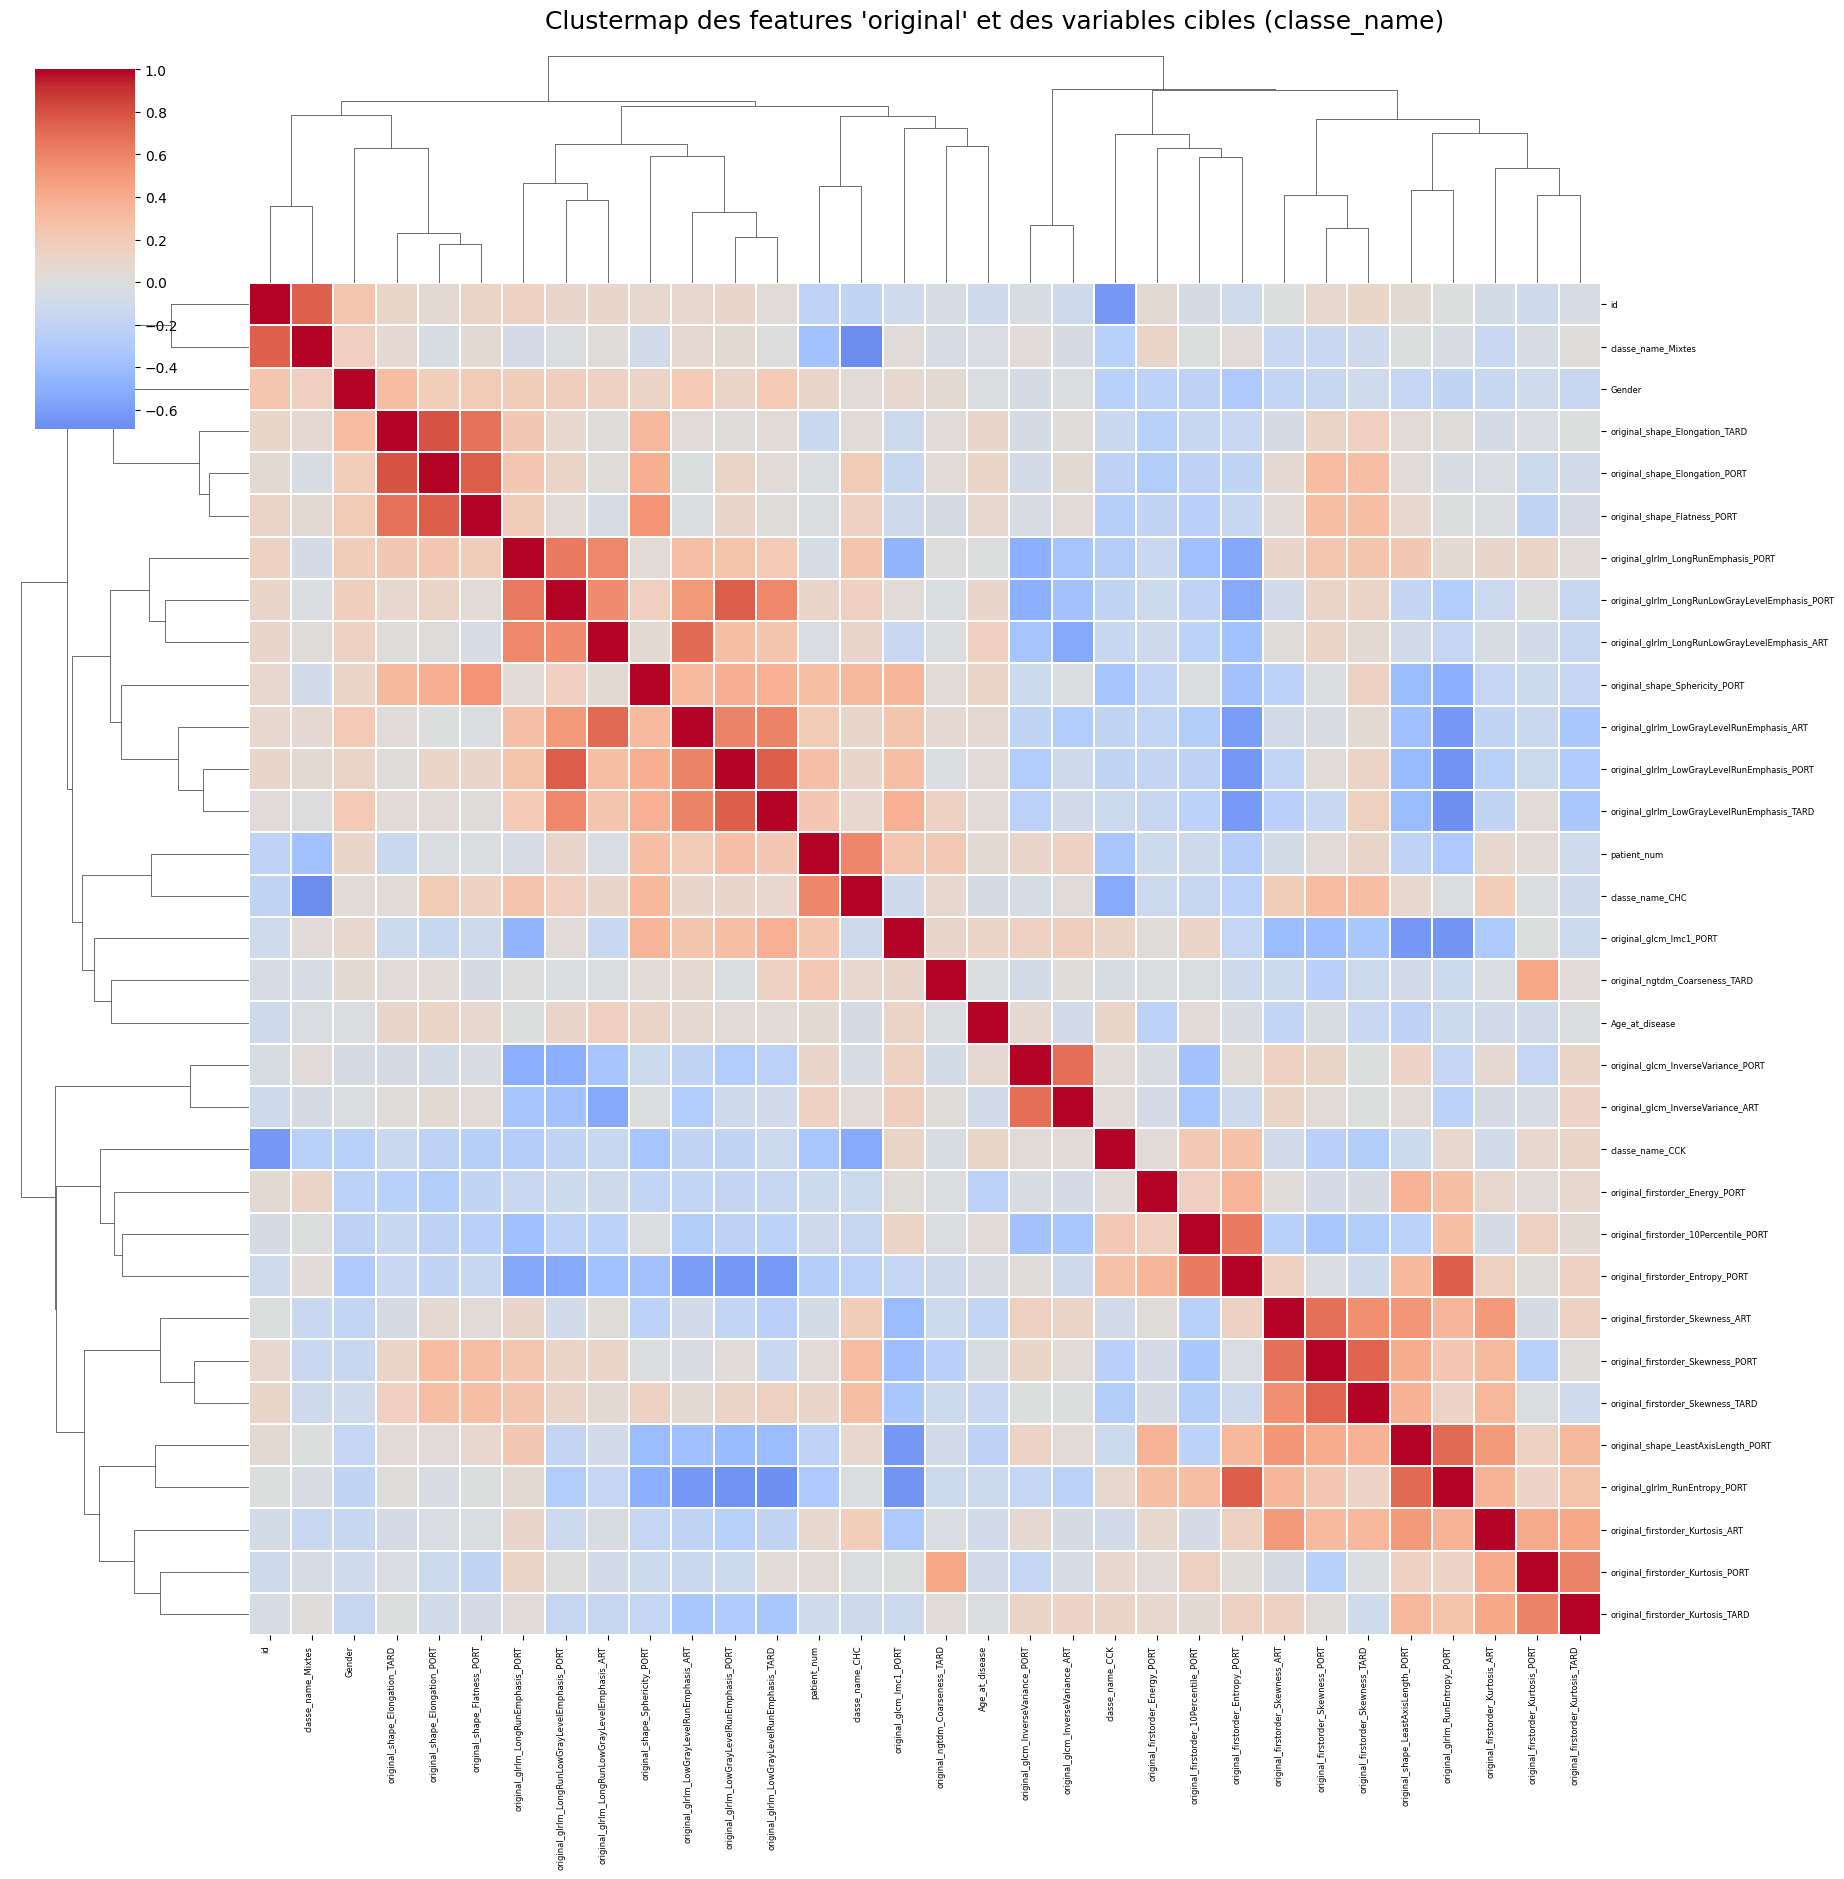

In [44]:
df_clean.to_csv("data/global_normalized_flattened_uncor_08.csv", sep = ";", index = False)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Sélection des features 'original' et de la cible 'classe_name'

df_corr = df_clean

# 2. Encodage de la cible en 3 colonnes distinctes (0 ou 1)
# Cela va créer : classe_name_CHC, classe_name_CCK, classe_name_Mixtes
df_encoded = pd.get_dummies(df_corr, columns=['classe_name'], dtype=int)

# 3. Calcul de la matrice de corrélation globale
corr_matrix_with_target = df_encoded.corr()

# 4. Création du Clustermap géant pour afficher TOUS les noms
g = sns.clustermap(
    corr_matrix_with_target, 
    cmap='coolwarm', 
    center=0, 
    figsize=(20, 20),       # Taille XXL (30x30) pour donner de l'espace au texte
    xticklabels=True,       # Affiche les noms en bas
    yticklabels=True,       # Affiche les noms sur le côté
    linewidths=0.05,        # Lignes très fines entre les cellules
    dendrogram_ratio=0.15   # Réduit la taille de l'arbre pour laisser plus de place à la carte
)

# 5. Ajustement précis de la police et de la rotation des étiquettes
# On utilise une taille de police de 6 pour éviter que les noms se marchent dessus
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=6, ha='right') 
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=6)

# Titre du graphique
plt.suptitle("Clustermap des features 'original' et des variables cibles (classe_name)", y=1.01, fontsize=18)

# Affichage
plt.show()

🚀 Lancement du Stratified GROUP K-Fold (5 Folds)
⚖️ Équilibrage automatique appliqué sur : Maladie + Sexe ('Gender') + Âge ('Age_at_disease')
Fold 1/5 - Accuracy: 0.90 | AUC: 0.73 | F1: 0.80 | MCC: 0.67
Fold 2/5 - Accuracy: 0.79 | AUC: 0.82 | F1: 0.73 | MCC: 0.48
Fold 3/5 - Accuracy: 0.95 | AUC: 0.98 | F1: 0.91 | MCC: 0.84
Fold 4/5 - Accuracy: 0.84 | AUC: 0.80 | F1: 0.65 | MCC: 0.46
Fold 5/5 - Accuracy: 0.83 | AUC: 0.98 | F1: 0.65 | MCC: 0.45

🏆 BILAN DES MÉTRIQUES ESSENTIELLES (MOYENNE ± ÉCART-TYPE)
Accuracy : 0.862 (± 0.055)
ROC AUC  : 0.863 (± 0.101)
F1-Score : 0.750 (± 0.099)
MCC      : 0.580 (± 0.152)


c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty=

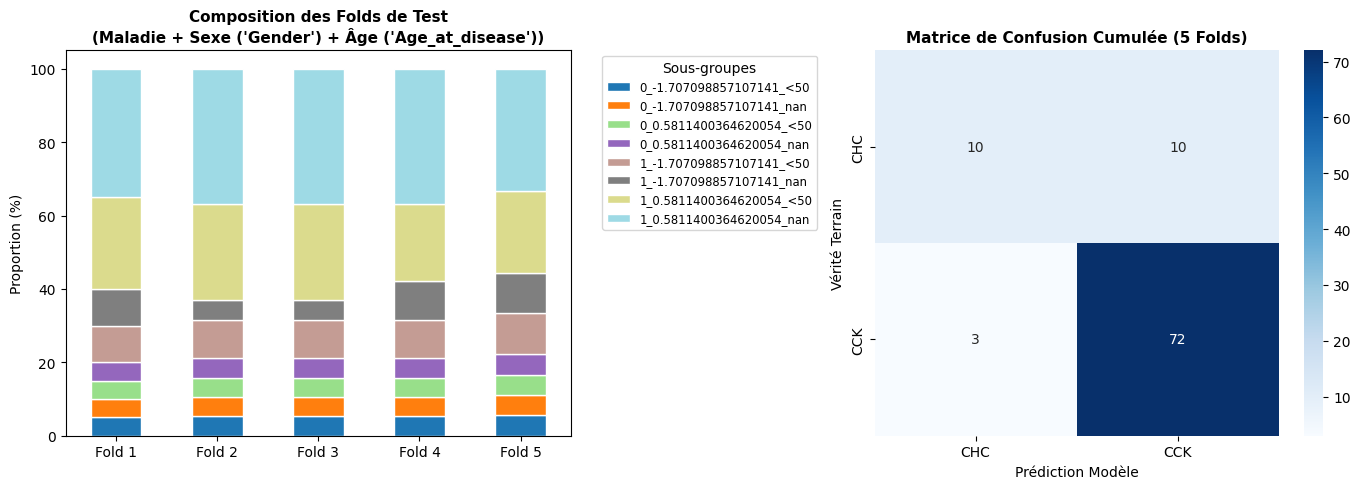

([0,
  0,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1],
 [np.float64(0.92072074045502),
  np.float64(0.2106689562998864),
  np.float64(0.0902565918576159),
  np.float64(0.8900229864536368),
  np.float64(0.9379399401986266),
  np.float64(0.9437241854872671),
  np.float64(0.6150861748798225),
  np.float64(0.560203696451778),
  np.float64(0.9127971155412767),
  np.float64(0.7618756227609859),
  np.float64(0.9085939511872129),
  np.float64(0.9724474970161652),
  np.float64(0.8338116374515377),
  np.float64(0.9175727383756396),
  np.float64(0.6128285028073404),
  np.float64(0.98

In [7]:
from validation import *
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("./data/flattened_global_scaled.csv", sep=";")

df = df[df["classe_name"] != "Mixtes"]

# Encodage textuel de la colonne cible ("CCK" et "CHC" -> 0 et 1)
label_encoder = LabelEncoder()
df["target"] = label_encoder.fit_transform(df["classe_name"])

# Sélection de toutes les features (en excluant les identifiants et la cible)
metadata_cols = ["id", "patient_num", "classe_name", "target"]
feature_cols = [col for col in df.columns if col not in metadata_cols]

X = df[feature_cols]
y = df["target"]

model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.5,
    random_state=42,
)

evaluer_modele_kfold(model, X, y, df, 'id', ['CHC', 'CCK'], col_age="Age_at_disease", col_sexe= "Gender")


In [29]:
import pandas as pd
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error

# 1. Chargement et fusion des données
df_clinique = pd.read_csv(r"data\Relectures_imageries.csv", sep=";")
df_radiomique = pd.read_csv(r"data\global_excel_resampled_normalized_flattened_deltas.csv", sep=";")

df_global = pd.merge(df_clinique, df_radiomique, on="id")

# 2. Le dictionnaire complet
correspondances = {
    "APHE_heterogeneous": ["original_shape_Maximum2DDiameterRow_ART", "original_shape_SurfaceVolumeRatio_TARD", "original_glrlm_GrayLevelNonUniformity_PORT"],
    "Bile_duct_dilatation": ["original_glszm_LargeAreaLowGrayLevelEmphasis_PORT", "original_gldm_LargeDependenceLowGrayLevelEmphasis_TARD", "original_glrlm_LongRunLowGrayLevelEmphasis_TARD"],
    "Blood": ["original_firstorder_Minimum_ART", "original_ngtdm_Busyness_ART", "original_ngtdm_Busyness_PORT"],
    "Capsule": ["original_shape_Sphericity_TARD", "original_shape_Sphericity_PORT", "original_shape_Flatness_TARD"],
    "Diffusion_targetoid": ["original_glcm_InverseVariance_PORT", "original_glcm_InverseVariance_ART", "original_glcm_InverseVariance_TARD"],
    "Intratumoral_fat": ["original_glcm_ClusterShade_TARD", "original_firstorder_Skewness_delta_ART_PORT", "original_glcm_ClusterShade_PORT"],
    "LR-5": ["original_firstorder_Median_TARD", "original_firstorder_Median_delta_TARD_ART", "original_gldm_LargeDependenceLowGrayLevelEmphasis_PORT"],
    "LR-M": ["original_ngtdm_Busyness_PORT", "original_firstorder_Median_TARD", "original_glszm_LargeAreaLowGrayLevelEmphasis_PORT"],
    "Late_enhancement": ["original_gldm_LargeDependenceHighGrayLevelEmphasis_TARD", "original_glrlm_LongRunHighGrayLevelEmphasis_TARD", "original_glszm_SmallAreaLowGrayLevelEmphasis_ART"],
    "Necrosis": ["original_shape_SurfaceVolumeRatio_TARD", "original_shape_SurfaceVolumeRatio_ART", "original_shape_SurfaceVolumeRatio_PORT"],
    "Nonperiph_washout": ["original_glszm_LargeAreaLowGrayLevelEmphasis_PORT", "original_firstorder_Skewness_TARD", "original_firstorder_10Percentile_delta_TARD_ART"],
    "Portal_thrombosis": ["original_shape_MajorAxisLength_ART", "original_shape_Maximum3DDiameter_ART", "original_shape_Maximum2DDiameterSlice_ART"],
    "Rim_APHE": ["original_firstorder_Median_TARD", "original_firstorder_Mean_TARD", "original_glszm_LargeAreaLowGrayLevelEmphasis_PORT"],
    "Satellite_nodule": ["original_shape_Sphericity_ART", "original_shape_Maximum3DDiameter_ART", "original_shape_Maximum3DDiameter_PORT"],
    "Shape": ["original_shape_Sphericity_ART", "original_shape_Sphericity_PORT"],
    "Size_mm": ["original_shape_SurfaceArea_TARD", "original_shape_SurfaceArea_PORT", "original_shape_SurfaceArea_ART"],
    "nonrim_APHE": ["original_firstorder_Median_TARD", "original_gldm_DependenceVariance_PORT", "original_gldm_DependenceNonUniformityNormalized_PORT"]
}

# 3. Création de la liste pour stocker les résultats
lignes_csv = []

print("==========================================================")
print("PERFORMANCES DES MODÈLES (AFFICHAGE CONSOLE)")
print("==========================================================\n")

# 4. Boucle de modélisation
for variable_y, features_x in correspondances.items():
    data_modele = df_global[[variable_y] + features_x].dropna()
    
    if len(data_modele) < 5:
        print(f"⚠️ {variable_y} : Pas assez de données disponibles.")
        continue
        
    X = data_modele[features_x]
    Y = data_modele[variable_y]
    valeurs_uniques = Y.unique()
    
    ligne_actuelle = {
        "Variable_Clinique": variable_y,
        "Nombre_Patients": len(data_modele)
    }
    
    # Classification (Régression Logistique)
    if len(valeurs_uniques) <= 5:
        modele = LogisticRegression(max_iter=1000)
        modele.fit(X, Y)
        predictions = modele.predict(X)
        
        # Calcul et affichage immédiat de l'Accuracy
        acc = accuracy_score(Y, predictions)
        print(f"📈 {variable_y:<22} | Modèle: Logistique | Accuracy: {acc * 100:.2f}%")
        
        ligne_actuelle["Type_Modele"] = "Logistique"
        ligne_actuelle["Intercept_Constante"] = round(modele.intercept_[0], 4)
        poids = modele.coef_[0]
        
    # Régression Continue (Linéaire)
    else:
        modele = LinearRegression()
        modele.fit(X, Y)
        predictions = modele.predict(X)
        
        # Calcul et affichage immédiat de l'erreur des moindres carrés (MSE)
        mse = mean_squared_error(Y, predictions)
        print(f"📉 {variable_y:<22} | Modèle: Linéaire   | Erreur Moindres Carrés (MSE): {mse:.4f}")
        
        ligne_actuelle["Type_Modele"] = "Linéaire"
        ligne_actuelle["Intercept_Constante"] = round(modele.intercept_, 4)
        poids = modele.coef_
        
    # Ajout dynamique des features et des poids pour le CSV
    for index, (nom_feature, valeur_poids) in enumerate(zip(features_x, poids)):
        numero = index + 1
        ligne_actuelle[f"Feature_{numero}"] = nom_feature
        ligne_actuelle[f"Poids_Feature_{numero}"] = round(valeur_poids, 4)
        
    lignes_csv.append(ligne_actuelle)

# 5. Conversion et sauvegarde du CSV (sans les métriques)
df_resultats = pd.DataFrame(lignes_csv)

colonnes_de_base = ["Variable_Clinique", "Type_Modele", "Nombre_Patients", "Intercept_Constante"]
colonnes_features = [col for col in df_resultats.columns if col.startswith("Feature_") or col.startswith("Poids_Feature_")]
df_resultats = df_resultats[colonnes_de_base + colonnes_features]

df_resultats = df_resultats.fillna("")
df_resultats.to_csv("poids_modeles_radiomiques.csv", sep=";", index=False, encoding="utf-8-sig")



PERFORMANCES DES MODÈLES (AFFICHAGE CONSOLE)

📈 APHE_heterogeneous     | Modèle: Logistique | Accuracy: 72.22%
📈 Bile_duct_dilatation   | Modèle: Logistique | Accuracy: 92.06%
📈 Blood                  | Modèle: Logistique | Accuracy: 80.95%
📈 Capsule                | Modèle: Logistique | Accuracy: 62.70%
📈 Diffusion_targetoid    | Modèle: Logistique | Accuracy: 94.12%
📈 Intratumoral_fat       | Modèle: Logistique | Accuracy: 83.33%
📈 LR-5                   | Modèle: Logistique | Accuracy: 60.32%
📈 LR-M                   | Modèle: Logistique | Accuracy: 65.87%
📈 Late_enhancement       | Modèle: Logistique | Accuracy: 76.98%
📈 Necrosis               | Modèle: Logistique | Accuracy: 84.92%
📈 Nonperiph_washout      | Modèle: Logistique | Accuracy: 69.05%
📈 Portal_thrombosis      | Modèle: Logistique | Accuracy: 85.71%
📈 Rim_APHE               | Modèle: Logistique | Accuracy: 64.29%
📈 Satellite_nodule       | Modèle: Logistique | Accuracy: 86.51%
📈 Shape                  | Modèle: Logistiqu

In [32]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression, LinearRegression
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score # <-- L'import manquant a été ajouté ici

# 1. Chargement et définition de df_global
df_clinique = pd.read_csv(r"data\Relectures_imageries.csv", sep=";")
df_radiomique = pd.read_csv(r"data\global_excel_resampled_normalized_flattened_deltas.csv", sep=";")

df_global = pd.merge(df_clinique, df_radiomique, on="id")

# 2. Dictionnaire complet des correspondances
correspondances = {
    "APHE_heterogeneous": ["original_shape_Maximum2DDiameterRow_ART", "original_shape_SurfaceVolumeRatio_TARD", "original_glrlm_GrayLevelNonUniformity_PORT"],
    "Bile_duct_dilatation": ["original_glszm_LargeAreaLowGrayLevelEmphasis_PORT", "original_gldm_LargeDependenceLowGrayLevelEmphasis_TARD", "original_glrlm_LongRunLowGrayLevelEmphasis_TARD"],
    "Blood": ["original_firstorder_Minimum_ART", "original_ngtdm_Busyness_ART", "original_ngtdm_Busyness_PORT"],
    "Capsule": ["original_shape_Sphericity_TARD", "original_shape_Sphericity_PORT", "original_shape_Flatness_TARD"],
    "Diffusion_targetoid": ["original_glcm_InverseVariance_PORT", "original_glcm_InverseVariance_ART", "original_glcm_InverseVariance_TARD"],
    "Intratumoral_fat": ["original_glcm_ClusterShade_TARD", "original_firstorder_Skewness_delta_ART_PORT", "original_glcm_ClusterShade_PORT"],
    "LR-5": ["original_firstorder_Median_TARD", "original_firstorder_Median_delta_TARD_ART", "original_gldm_LargeDependenceLowGrayLevelEmphasis_PORT"],
    "LR-M": ["original_ngtdm_Busyness_PORT", "original_firstorder_Median_TARD", "original_glszm_LargeAreaLowGrayLevelEmphasis_PORT"],
    "Late_enhancement": ["original_gldm_LargeDependenceHighGrayLevelEmphasis_TARD", "original_glrlm_LongRunHighGrayLevelEmphasis_TARD", "original_glszm_SmallAreaLowGrayLevelEmphasis_ART"],
    "Necrosis": ["original_shape_SurfaceVolumeRatio_TARD", "original_shape_SurfaceVolumeRatio_ART", "original_shape_SurfaceVolumeRatio_PORT"],
    "Nonperiph_washout": ["original_glszm_LargeAreaLowGrayLevelEmphasis_PORT", "original_firstorder_Skewness_TARD", "original_firstorder_10Percentile_delta_TARD_ART"],
    "Portal_thrombosis": ["original_shape_MajorAxisLength_ART", "original_shape_Maximum3DDiameter_ART", "original_shape_Maximum2DDiameterSlice_ART"],
    "Rim_APHE": ["original_firstorder_Median_TARD", "original_firstorder_Mean_TARD", "original_glszm_LargeAreaLowGrayLevelEmphasis_PORT"],
    "Satellite_nodule": ["original_shape_Sphericity_ART", "original_shape_Maximum3DDiameter_ART", "original_shape_Maximum3DDiameter_PORT"],
    "Shape": ["original_shape_Sphericity_ART", "original_shape_Sphericity_PORT"],
    "Size_mm": ["original_shape_SurfaceArea_TARD", "original_shape_SurfaceArea_PORT", "original_shape_SurfaceArea_ART"],
    "nonrim_APHE": ["original_firstorder_Median_TARD", "original_gldm_DependenceVariance_PORT", "original_gldm_DependenceNonUniformityNormalized_PORT"]
}

# 3. Génération des variables composites dans df_global
for variable_y, features_x in correspondances.items():
    data_modele = df_global[[variable_y] + features_x].dropna()
    if len(data_modele) < 5:
        continue
        
    X = data_modele[features_x]
    Y = data_modele[variable_y]
    valeurs_uniques = Y.unique()
    
    # Conservation des index pour replacer les valeurs au bon endroit
    index_valides = data_modele.index
    nom_composite = f"Composite_Pred_{variable_y}"
    
    if len(valeurs_uniques) <= 5:
        modele = LogisticRegression(max_iter=1000)
        modele.fit(X, Y)
        # On récupère la probabilité de la classe 1 (événement présent)
        if len(valeurs_uniques) == 2:
            preds = modele.predict_proba(X)[:, 1]
        else:
            # Pour Shape (0, 1, 2), on prend la prédiction directe
            preds = modele.predict(X) 
        df_global.loc[index_valides, nom_composite] = preds
    else:
        modele = LinearRegression()
        modele.fit(X, Y)
        df_global.loc[index_valides, nom_composite] = modele.predict(X)

# 4. Définition complète des paires à tester
paires_a_tester = {
    "APHE_heterogeneous": "Composite_Pred_APHE_heterogeneous",
    "Bile_duct_dilatation": "Composite_Pred_Bile_duct_dilatation",
    "Blood": "Composite_Pred_Blood",
    "Capsule": "Composite_Pred_Capsule",
    "Diffusion_targetoid": "Composite_Pred_Diffusion_targetoid",
    "Intratumoral_fat": "Composite_Pred_Intratumoral_fat",
    "LR-5": "Composite_Pred_LR-5",
    "LR-M": "Composite_Pred_LR-M",
    "Late_enhancement": "Composite_Pred_Late_enhancement",
    "Necrosis": "Composite_Pred_Necrosis",
    "Nonperiph_washout": "Composite_Pred_Nonperiph_washout",
    "Portal_thrombosis": "Composite_Pred_Portal_thrombosis",
    "Rim_APHE": "Composite_Pred_Rim_APHE",
    "Satellite_nodule": "Composite_Pred_Satellite_nodule",
    "Shape": "Composite_Pred_Shape",
    "Size_mm": "Composite_Pred_Size_mm",
    "nonrim_APHE": "Composite_Pred_nonrim_APHE"
}

# 5. Calcul et affichage des corrélations et AUC
print("==========================================================")
print("ÉVALUATION : RÉALITÉ CLINIQUE vs PRÉDICTIONS COMPOSITES")
print("==========================================================\n")

for vraie_var, comp_var in paires_a_tester.items():
    if vraie_var in df_global.columns and comp_var in df_global.columns:
        # Nettoyage des NaN
        data_clean = df_global[[vraie_var, comp_var]].dropna()
        
        if len(data_clean) > 0:
            valeurs_uniques = data_clean[vraie_var].unique()
            
            # CAS 1 : C'est une variable binaire (0 ou 1) -> On utilise l'AUC-ROC
            if len(valeurs_uniques) == 2:
                try:
                    auc = roc_auc_score(data_clean[vraie_var], data_clean[comp_var])
                    print(f"{vraie_var:<25} | AUC-ROC = {auc:.4f} (Métrique Binaire)")
                except ValueError:
                    print(f"{vraie_var:<25} | Erreur AUC (Vérifier s'il n'y a qu'une seule classe présente)")
                    
            # CAS 2 : C'est une variable continue ou multiclasses -> On garde Spearman
            else:
                correlation, p_value = spearmanr(data_clean[vraie_var], data_clean[comp_var])
                print(f"{vraie_var:<25} | Spearman r = {correlation:+.4f} (p={p_value:.4f})")
    else:
        print(f"{vraie_var:<25} | Ignoré (Colonnes manquantes)")

ÉVALUATION : RÉALITÉ CLINIQUE vs PRÉDICTIONS COMPOSITES

APHE_heterogeneous        | AUC-ROC = 0.8050 (Métrique Binaire)
Bile_duct_dilatation      | AUC-ROC = 0.8250 (Métrique Binaire)
Blood                     | AUC-ROC = 0.7714 (Métrique Binaire)
Capsule                   | AUC-ROC = 0.6648 (Métrique Binaire)
Diffusion_targetoid       | AUC-ROC = 0.7232 (Métrique Binaire)
Intratumoral_fat          | AUC-ROC = 0.6249 (Métrique Binaire)
LR-5                      | AUC-ROC = 0.6762 (Métrique Binaire)
LR-M                      | AUC-ROC = 0.7279 (Métrique Binaire)
Late_enhancement          | AUC-ROC = 0.7422 (Métrique Binaire)
Necrosis                  | AUC-ROC = 0.8635 (Métrique Binaire)
Nonperiph_washout         | AUC-ROC = 0.6726 (Métrique Binaire)
Portal_thrombosis         | AUC-ROC = 0.8813 (Métrique Binaire)
Rim_APHE                  | AUC-ROC = 0.6609 (Métrique Binaire)
Satellite_nodule          | AUC-ROC = 0.8830 (Métrique Binaire)
Shape                     | Spearman r = +0.536

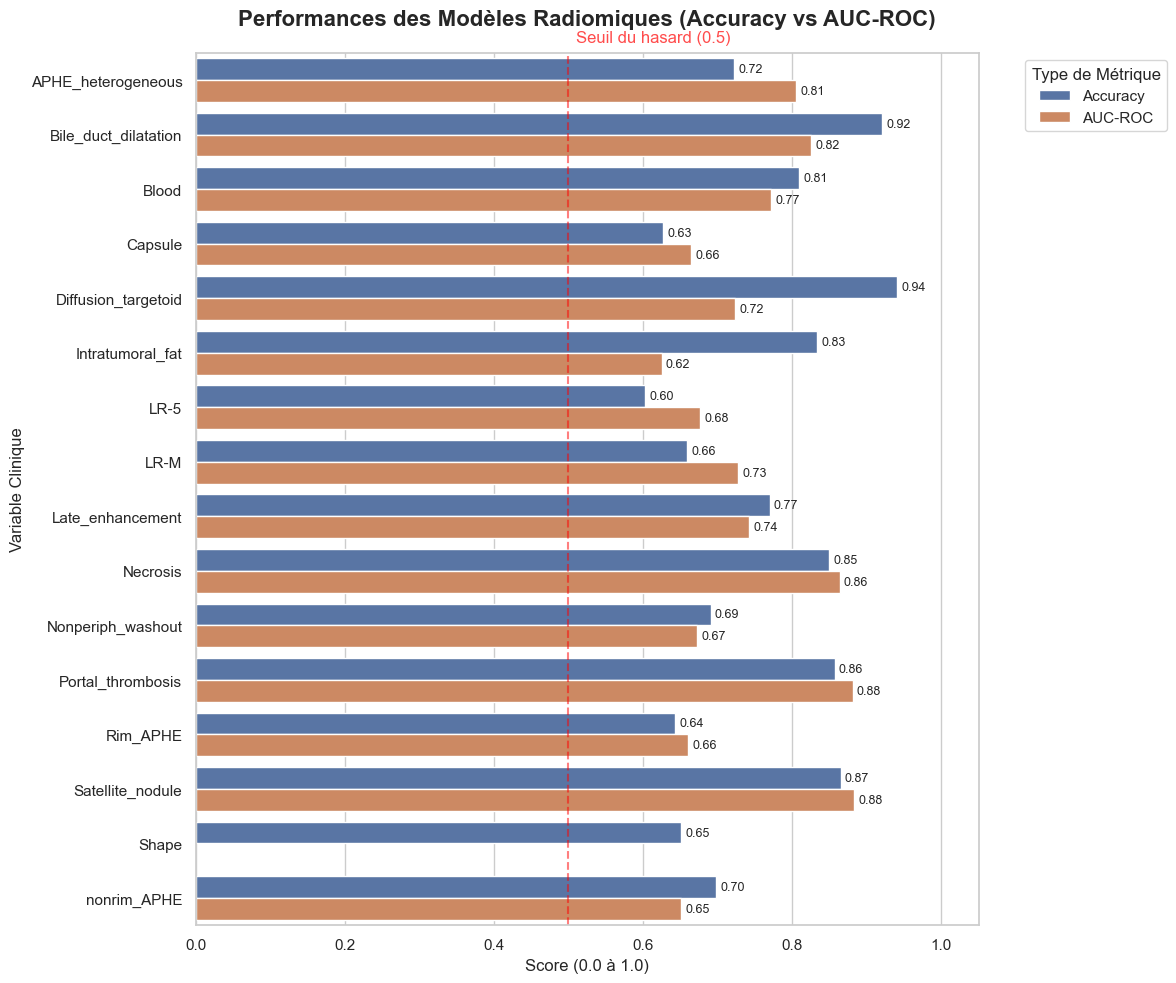

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# 1. Chargement des données
df_clinique = pd.read_csv(r"data\Relectures_imageries.csv", sep=";")
df_radiomique = pd.read_csv(r"data\global_excel_resampled_normalized_flattened_deltas.csv", sep=";")
df_global = pd.merge(df_clinique, df_radiomique, on="id")

# 2. Ton dictionnaire de correspondances
correspondances = {
    "APHE_heterogeneous": ["original_shape_Maximum2DDiameterRow_ART", "original_shape_SurfaceVolumeRatio_TARD", "original_glrlm_GrayLevelNonUniformity_PORT"],
    "Bile_duct_dilatation": ["original_glszm_LargeAreaLowGrayLevelEmphasis_PORT", "original_gldm_LargeDependenceLowGrayLevelEmphasis_TARD", "original_glrlm_LongRunLowGrayLevelEmphasis_TARD"],
    "Blood": ["original_firstorder_Minimum_ART", "original_ngtdm_Busyness_ART", "original_ngtdm_Busyness_PORT"],
    "Capsule": ["original_shape_Sphericity_TARD", "original_shape_Sphericity_PORT", "original_shape_Flatness_TARD"],
    "Diffusion_targetoid": ["original_glcm_InverseVariance_PORT", "original_glcm_InverseVariance_ART", "original_glcm_InverseVariance_TARD"],
    "Intratumoral_fat": ["original_glcm_ClusterShade_TARD", "original_firstorder_Skewness_delta_ART_PORT", "original_glcm_ClusterShade_PORT"],
    "LR-5": ["original_firstorder_Median_TARD", "original_firstorder_Median_delta_TARD_ART", "original_gldm_LargeDependenceLowGrayLevelEmphasis_PORT"],
    "LR-M": ["original_ngtdm_Busyness_PORT", "original_firstorder_Median_TARD", "original_glszm_LargeAreaLowGrayLevelEmphasis_PORT"],
    "Late_enhancement": ["original_gldm_LargeDependenceHighGrayLevelEmphasis_TARD", "original_glrlm_LongRunHighGrayLevelEmphasis_TARD", "original_glszm_SmallAreaLowGrayLevelEmphasis_ART"],
    "Necrosis": ["original_shape_SurfaceVolumeRatio_TARD", "original_shape_SurfaceVolumeRatio_ART", "original_shape_SurfaceVolumeRatio_PORT"],
    "Nonperiph_washout": ["original_glszm_LargeAreaLowGrayLevelEmphasis_PORT", "original_firstorder_Skewness_TARD", "original_firstorder_10Percentile_delta_TARD_ART"],
    "Portal_thrombosis": ["original_shape_MajorAxisLength_ART", "original_shape_Maximum3DDiameter_ART", "original_shape_Maximum2DDiameterSlice_ART"],
    "Rim_APHE": ["original_firstorder_Median_TARD", "original_firstorder_Mean_TARD", "original_glszm_LargeAreaLowGrayLevelEmphasis_PORT"],
    "Satellite_nodule": ["original_shape_Sphericity_ART", "original_shape_Maximum3DDiameter_ART", "original_shape_Maximum3DDiameter_PORT"],
    "Shape": ["original_shape_Sphericity_ART", "original_shape_Sphericity_PORT"],
    "nonrim_APHE": ["original_firstorder_Median_TARD", "original_gldm_DependenceVariance_PORT", "original_gldm_DependenceNonUniformityNormalized_PORT"]
    # J'ai retiré Size_mm car c'est une régression continue (pas d'Accuracy ni d'AUC)
}

# 3. Calcul des métriques
resultats = []

for variable_y, features_x in correspondances.items():
    data_modele = df_global[[variable_y] + features_x].dropna()
    
    if len(data_modele) < 5:
        continue
        
    X = data_modele[features_x]
    Y = data_modele[variable_y]
    valeurs_uniques = Y.unique()
    
    # On ne traite que les variables de classification (<= 5 classes)
    if len(valeurs_uniques) <= 5:
        modele = LogisticRegression(max_iter=1000)
        modele.fit(X, Y)
        
        # Prédictions directes (0 ou 1) pour l'Accuracy
        preds_class = modele.predict(X)
        acc = accuracy_score(Y, preds_class)
        resultats.append({"Variable": variable_y, "Métrique": "Accuracy", "Score": acc})
        
        # Prédictions en probabilités pour l'AUC-ROC (uniquement pour les variables binaires)
        if len(valeurs_uniques) == 2:
            try:
                preds_proba = modele.predict_proba(X)[:, 1]
                auc = roc_auc_score(Y, preds_proba)
                resultats.append({"Variable": variable_y, "Métrique": "AUC-ROC", "Score": auc})
            except ValueError:
                pass

# 4. Création du graphique (Plot) avec Seaborn
df_plot = pd.DataFrame(resultats)

# Configuration du style visuel
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 10))

# Création du graphique en barres horizontales (orient="h")
ax = sns.barplot(
    data=df_plot, 
    x="Score", 
    y="Variable", 
    hue="Métrique",
    palette={"Accuracy": "#4C72B0", "AUC-ROC": "#DD8452"}
)

# Personnalisation
plt.title("Performances des Modèles Radiomiques (Accuracy vs AUC-ROC)", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Score (0.0 à 1.0)", fontsize=12)
plt.ylabel("Variable Clinique", fontsize=12)
plt.xlim(0, 1.05)
plt.legend(title="Type de Métrique", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ligne verticale à 0.5 pour marquer le seuil de "hasard" pour l'AUC
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.5)
plt.text(0.51, ax.get_ylim()[1]-0.2, "Seuil du hasard (0.5)", color='red', alpha=0.7)

# Affichage des valeurs directement sur les barres pour faciliter la lecture
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

# Ajustement des marges et affichage
plt.tight_layout()
plt.show()